Text(0.5, 1.0, 'Annealed Approximation: Lotka-Volterra')

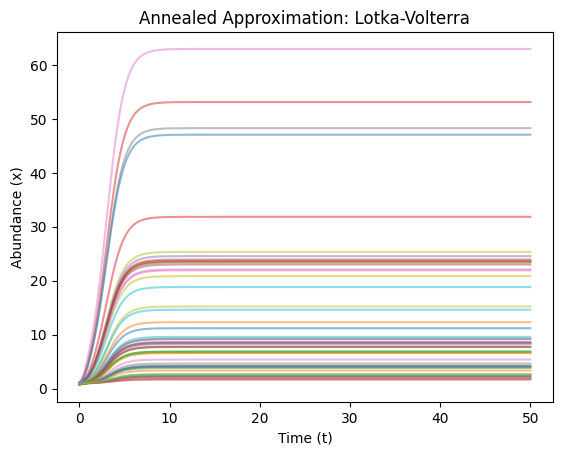

In [15]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# 1. Set Parameters
N = 3000       # Number of species to simulate
mu = 0.51     # Interaction strength (negative = competitive, positive = cooperative)

# 2. Sample the degrees (g) directly from a distribution
# We use an exponential distribution where the mean degree g = 1
# This completely bypasses the need for an adjacency matrix
g = np.random.exponential(scale=1.0, size=N)

# 3. Set initial abundances (x0)
# Drawn from a truncated normal distribution around 1.0 (as specified in Appendix B)
x0 = np.random.normal(loc=1.0, scale=0.1, size=N)
x0 = np.maximum(0.1, x0) # Ensure no negative starting populations

# 4. Define the Annealed Mean-Field ODE
def annealed_lotka_volterra(x, t, g, mu):
    # Calculate the global cavity average M(t) at this time step
    # M(t) = average of (degree * abundance)
    M = np.mean(g * x)
    
    # Calculate the rate of change for all species simultaneously
    # dx/dt = x * (1 - x + g * mu * M)
    dxdt = x * (1 - x + g * mu * M)
    return dxdt

# 5. Integrate over time
t_span = np.linspace(0, 50, 500)
x_t = odeint(annealed_lotka_volterra, x0, t_span, args=(g, mu))

# Optional: Plot the results for the first 50 species
plt.plot(t_span, x_t[:, :50], alpha=0.5)
plt.xlabel('Time (t)')
plt.ylabel('Abundance (x)')
plt.title('Annealed Approximation: Lotka-Volterra')